
# Linear Regression — Batch Gradient Descent Demo

This notebook uses the data:
- **x** = [1, 2, 3, 4, 5]  
- **y** = [5, 6, 10, 13, 11]

We compute predictions for `b0 = 3`, `b1 = 1.9`, perform **one** batch gradient-descent update with `alpha = 0.1`, then run multiple iterations and plot cost vs iterations.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data
x = np.array([1,2,3,4,5], dtype=float)
y = np.array([5,6,10,13,11], dtype=float)
m = len(x)


In [2]:

# initial parameters
b0 = 3.0
b1 = 1.9
alpha = 0.1

def predict(b0, b1, x):
    return b0 + b1 * x

y_pred = predict(b0, b1, x)
residuals = y_pred - y

df = pd.DataFrame({
    'x': x,
    'y_true': y,
    'y_pred': y_pred,
    'residual': residuals,
    'abs_residual': np.abs(residuals),
    'squared_error': residuals**2
})
df


,x,y_true,y_pred,residual,abs_residual,squared_error
0,1.0,5.0,4.9,-0.1,0.1,0.01
1,2.0,6.0,6.8,0.8,0.8,0.64
2,3.0,10.0,8.7,-1.3,1.3,1.69
3,4.0,13.0,10.6,-2.4,2.4,5.76
4,5.0,11.0,12.5,1.5,1.5,2.25


In [3]:

# Batch gradient computation
db0 = np.sum(residuals) / m
db1 = np.sum(residuals * x) / m

b0_new = b0 - alpha * db0
b1_new = b1 - alpha * db1

print(f'Gradient db0 = {db0:.6f}, db1 = {db1:.6f}')
print(f'Updated parameters: b0_new = {b0_new:.6f}, b1_new = {b1_new:.6f}')

# new predictions after update
y_pred_new = predict(b0_new, b1_new, x)
print('\nNew predictions: ', np.round(y_pred_new, 4))


Gradient db0 = -0.300000, db1 = -0.900000
Updated parameters: b0_new = 3.030000, b1_new = 1.990000

New predictions:  [ 5.02  7.01  9.   10.99 12.98]


In [4]:

def cost(b0, b1, x, y):
    m = len(x)
    preds = predict(b0, b1, x)
    return (1/(2*m)) * np.sum((preds - y)**2)

print(f'Cost before update: {cost(b0,b1,x,y):.6f}')
print(f'Cost after update:  {cost(b0_new,b1_new,x,y):.6f}')


Cost before update: 1.035000
Cost after update:  0.998100


In [5]:

# Run multiple batch GD iterations
def batch_gradient_descent(b0_init, b1_init, x, y, alpha=0.1, epochs=100):
    b0 = b0_init
    b1 = b1_init
    history = []
    for epoch in range(1, epochs+1):
        preds = predict(b0,b1,x)
        err = preds - y
        db0 = np.sum(err) / m
        db1 = np.sum(err * x) / m
        b0 = b0 - alpha * db0
        b1 = b1 - alpha * db1
        c = cost(b0,b1,x,y)
        history.append((epoch, b0, b1, c))
    return np.array(history)

history = batch_gradient_descent(b0, b1, x, y, alpha=alpha, epochs=100)

# show last few rows
history[-10:]


array([[ 91.        ,   3.24095061,   1.91635573,   0.99031733],
       [ 92.        ,   3.24194883,   1.91607924,   0.99030669],
       [ 93.        ,   3.24293018,   1.91580743,   0.99029641],
       [ 94.        ,   3.24389493,   1.9155402 ,   0.99028648],
       [ 95.        ,   3.24484338,   1.9152775 ,   0.99027687],
       [ 96.        ,   3.24577579,   1.91501924,   0.99026759],
       [ 97.        ,   3.24669244,   1.91476534,   0.99025862],
       [ 98.        ,   3.24759359,   1.91451573,   0.99024995],
       [ 99.        ,   3.24847951,   1.91427035,   0.99024157],
       [100.        ,   3.24935046,   1.91402911,   0.99023347]])

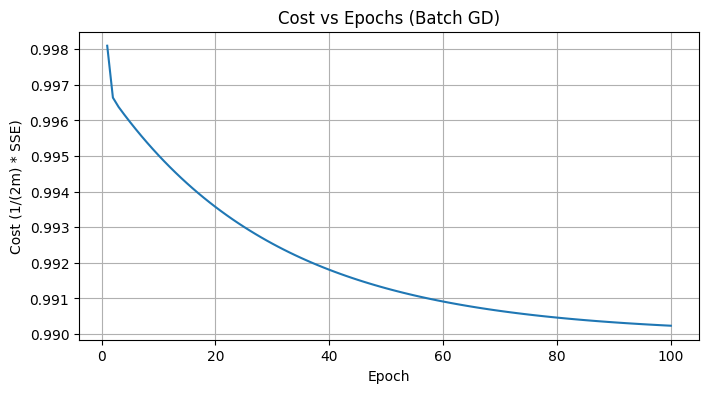

In [6]:

# Plot cost vs epochs
epochs = history[:,0]
costs = history[:,3]

plt.figure(figsize=(8,4))
plt.plot(epochs, costs)
plt.xlabel('Epoch')
plt.ylabel('Cost (1/(2m) * SSE)')
plt.title('Cost vs Epochs (Batch GD)')
plt.grid(True)
plt.show()


In [7]:

b0_final = history[-1,1]
b1_final = history[-1,2]

summary = pd.DataFrame({
    'param': ['b0_init','b1_init','b0_final','b1_final','cost_init','cost_final'],
    'value': [b0, b1, b0_final, b1_final, cost(b0,b1,x,y), cost(b0_final,b1_final,x,y)]
})
summary


,param,value
0,b0_init,3.000000
1,b1_init,1.900000
2,b0_final,3.249350
3,b1_final,1.914029
4,cost_init,1.035000
5,cost_final,0.990233
